# Tutorial 3



## Setup


In [1]:
# Installing Preliz if necessary
!pip install preliz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [2]:
%matplotlib inline
import arviz as az
import matplotlib.pyplot as plt
import pymc as pm
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

from google.colab import files
import preliz as pz

In [3]:
# Random generator for reproducible simulations
rng = np.random.default_rng(123)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (7, 4)

In [4]:
az.style.use("arviz-darkgrid")
sns.set_style("darkgrid")

## Load data



In [5]:
# Load the dataset
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
df.head()

Saving ‏‏big_startup_secsses_datase_ISR.csv to ‏‏big_startup_secsses_datase_ISR.csv


,name,status,country_code,funding_total_usd,category_list
0,eMotion Technologies,operating,ISR,10000,Games
1,Microstrip Planar Antennas,operating,ISR,800000,Messaging
2,Integrity Applications,ipo,ISR,22607446,Health Care
3,RBNanDoors,operating,ISR,11000000,Design|Manufacturing|Public Safety|Security
4,Mobilicom,operating,ISR,Nan,Mobile Commerce|Telecommunications|Wireless


In [6]:
# Create the binary Biotechnology variable
# biotech = 1 if "Biotechnology" appears anywhere in category_list, 0 otherwise

df["category_list"] = df["category_list"].astype(str).str.strip()

df["biotech"] = (
    df["category_list"]
    .str.contains("Biotechnology", case=False, na=False)
    .astype(int)
)

df[["category_list", "biotech"]].head()

,category_list,biotech
0,Games,0
1,Messaging,0
2,Health Care,0
3,Design|Manufacturing|Public Safety|Security,0
4,Mobile Commerce|Telecommunications|Wireless,0


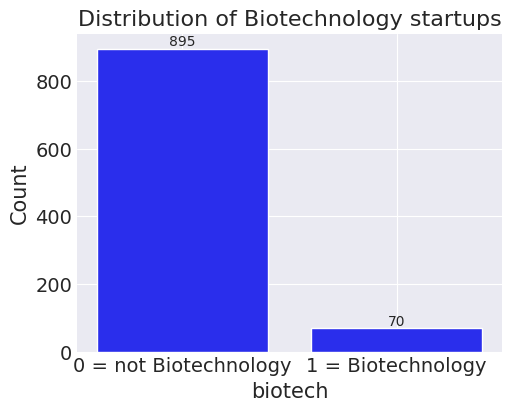

In [7]:
# Plot the Biotechnology variable
counts = df["biotech"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
bars = plt.bar(counts.index, counts.values)

plt.xticks([0, 1], ["0 = not Biotechnology", "1 = Biotechnology"])
plt.xlabel("biotech")
plt.ylabel("Count")
plt.title("Distribution of Biotechnology startups")

for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01, f"{int(v)}", ha="center")

plt.show()


In [8]:
# Basic summaries
data = df["biotech"].to_numpy()

n = len(data)
k = data.sum()
theta_hat = data.mean()

print(f"Number of startups: {n}")
print(f"Number of Biotechnology startups: {k}")
print(f"Observed Biotechnology rate: {theta_hat:.4f}")

Number of startups: 965
Number of Biotechnology startups: 70
Observed Biotechnology rate: 0.0725


# Modeling Biotechnology company category rate

In [9]:
# Choosing a prior
# Let's say I belive 10% of startups belong to the "Biotechnology" category.
# I can choose a "weak" prior Beta(2,18) - I saw alpha-1 successes & beta-1 failures
# or I can choose a "strong" prior Beta(10, 90)

# Weaker prior (but still informative)
a = 2
b = 18

# # Stronger prior - narrower distribution
# a = 10
# b = 90

# # Flap prior (no prior knowledge)
# a = 1
# b = 1

pz.Beta(alpha=a, beta=b).plot_interactive()


/usr/local/lib/python3.12/dist-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run XlogY0's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


interactive(children=(FloatSlider(value=2.0, description='alpha (0, inf)', max=12.0, min=2.220446049250313e-16…

### PyMC

In [10]:
# coords - naming our data
coords = {"startup": np.arange(len(data))}

# First PyMC model
with pm.Model(coords=coords) as biotech_model:
    theta = pm.Beta("theta", alpha=a, beta=b)
    y = pm.Bernoulli("y", p=theta, observed=data, dims='startup')

    idata = pm.sample(1000, chains=4, random_seed=17)

Output()

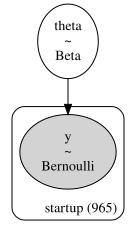

In [11]:
pm.model_to_graphviz(biotech_model)

#### Inference Data Object

In [12]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

#### Posterior

In [13]:
#we can save an xarray of the posterior information
posterior = idata.posterior.theta
posterior.shape #and see that the shape is 1000 draws for 4 chains

(4, 1000)

In [14]:
#we can also convert the information into a numpy array
posterior_np = posterior.to_numpy()
posterior_np

array([[0.08096988, 0.07666494, 0.08107013, ..., 0.06290256, 0.07734294,
        0.07345088],
       [0.08327295, 0.08320612, 0.08320612, ..., 0.06660646, 0.07146465,
        0.0583416 ],
       [0.07848925, 0.07502187, 0.07844976, ..., 0.0762971 , 0.07254998,
        0.07432737],
       [0.06806662, 0.07750158, 0.0746489 , ..., 0.06551594, 0.08219907,
        0.08505107]])

#### Analyzing the Posterior

array([[<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'theta'}>]], dtype=object)

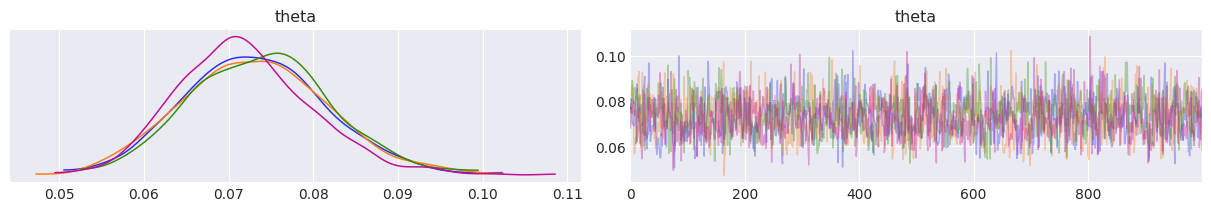

In [15]:
az.plot_trace(idata, compact=False)

#### Means of Chains

In [16]:
ms = idata.posterior.mean(dim = 'draw')
print(f'The means of the 4 chains are: {np.round(ms.theta.to_numpy(), 3)}')

The means of the 4 chains are: [0.073 0.073 0.074 0.072]


#### comparing with our analytical results


/usr/local/lib/python3.12/dist-packages/pytensor/tensor/xlogx.py:47: RuntimeWarning: divide by zero encountered in log
  return x * np.log(y)


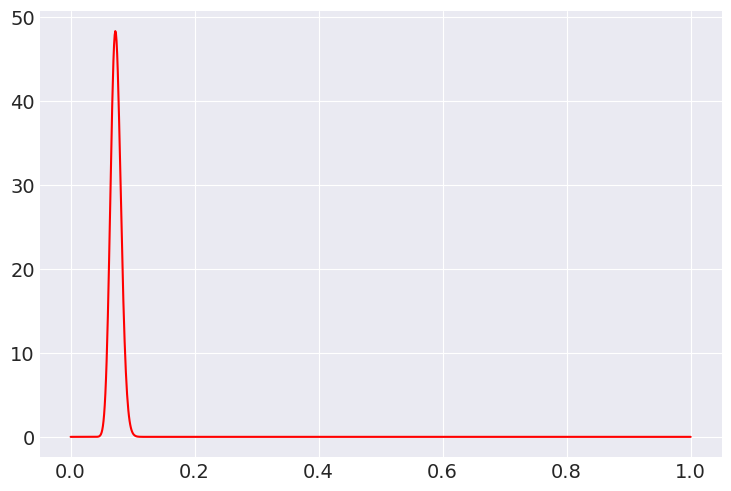

In [17]:
#comparing with our analytical results
alpha_prior = 2
beta_prior = 18
theta_grid = np.linspace(0, 1, 1000)

posterior_analytical = pz.Beta(alpha_prior + k, beta_prior + n - k).pdf(theta_grid)
plt.plot(theta_grid, posterior_analytical, color='red')


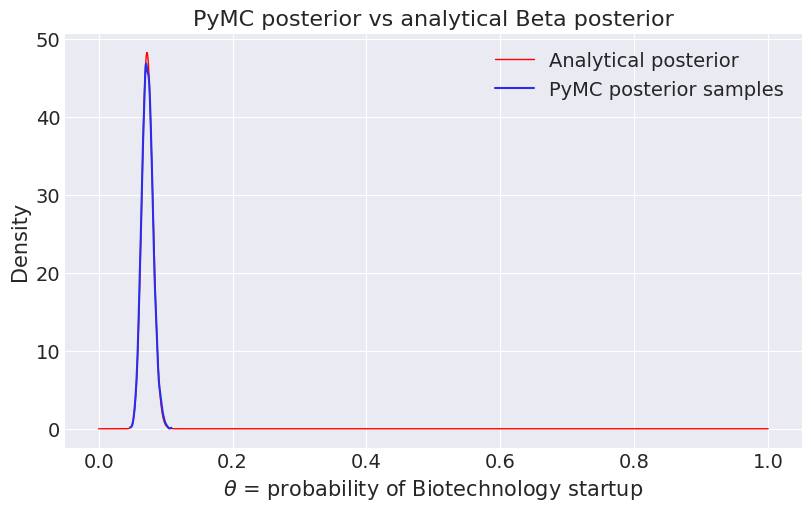

In [18]:
# Compare PyMC posterior samples with analytical posterior

# PyMC posterior samples
posterior_samples = az.extract(idata, var_names=["theta"]).to_numpy()

plt.figure(figsize=(8, 5))

# Analytical posterior
plt.plot(
    theta_grid,
    posterior_analytical,
    color="red",
    linewidth=1,
    label="Analytical posterior"
)

# PyMC sampled posterior
az.plot_kde(
    posterior_samples,
    label="PyMC posterior samples"
)


plt.xlabel(r"$\theta$ = probability of Biotechnology startup")
plt.ylabel("Density")
plt.title("PyMC posterior vs analytical Beta posterior")
plt.legend()
plt.show()

#### Effect of number of samples (draws)


The means of the 4 chains are: [0.0732 0.0732 0.0739 0.0719]


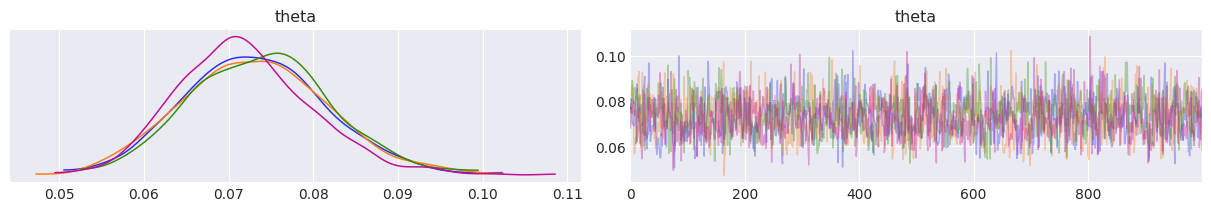

In [19]:
# Previous Model with 1000 posterior draws per chain
az.plot_trace(idata, compact=False)

ms = idata.posterior.mean(dim="draw")
print(f"The means of the 4 chains are: {np.round(ms.theta.to_numpy(), 4)}")

In [20]:
# Same model with 10000 posterior draws per chain

with pm.Model(coords=coords) as biotech_model_10000:
    theta = pm.Beta("theta", alpha=a, beta=b)
    y = pm.Bernoulli("y", p=theta, observed=data, dims="startup")

    idata10000 = pm.sample(10000, chains=4, random_seed=17)

Output()

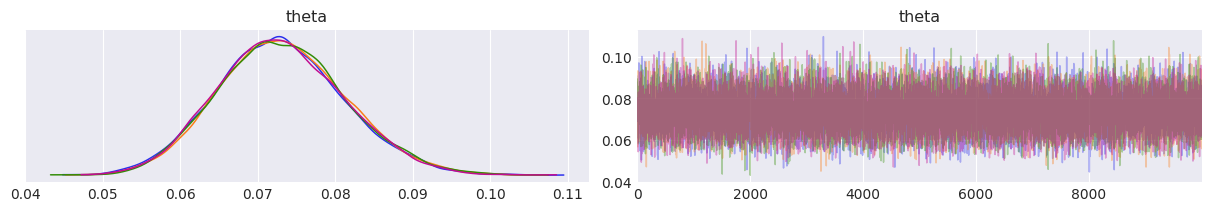

The means of the 4 chains are: [0.0729 0.0733 0.0733 0.073 ]


In [21]:
# Trace plot
az.plot_trace(idata10000, compact=False)
plt.show()

ms = idata10000.posterior.mean(dim="draw")
print(f"The means of the 4 chains are: {np.round(ms.theta.to_numpy(), 4)}")

In [22]:
# Posterior samples from the first model
posterior = idata.posterior.theta
posterior

<xarray.DataArray 'theta' (chain: 4, draw: 1000)> Size: 32kB
array([[0.08096988, 0.07666494, 0.08107013, ..., 0.06290256, 0.07734294,
        0.07345088],
       [0.08327295, 0.08320612, 0.08320612, ..., 0.06660646, 0.07146465,
        0.0583416 ],
       [0.07848925, 0.07502187, 0.07844976, ..., 0.0762971 , 0.07254998,
        0.07432737],
       [0.06806662, 0.07750158, 0.0746489 , ..., 0.06551594, 0.08219907,
        0.08505107]])
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

array([[<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'theta'}>]], dtype=object)

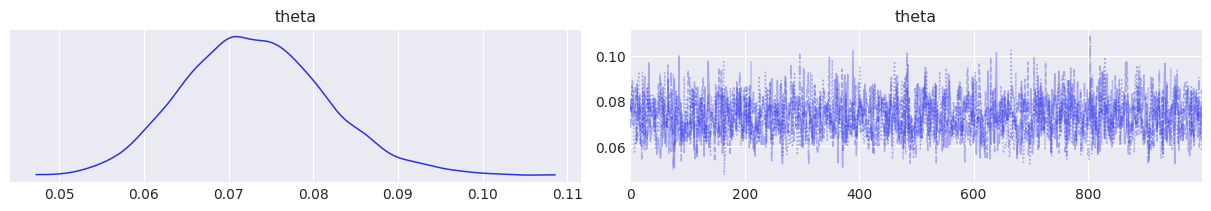

In [23]:
# Combine the 4 chains in the trace plot - we don't usually do it, just for you to see the option
az.plot_trace(idata, combined=True)


In [24]:
# Overall posterior mean across all chains and draws
m = idata.posterior.mean()

print(f"The total mean of the posterior samples is: {np.round(m.theta.to_numpy(), 4)}")

The total mean of the posterior samples is: 0.073


In [25]:
# Get all posterior samples as one combined object

posterior_samples = az.extract(idata)
posterior_samples

<xarray.Dataset> Size: 128kB
Dimensions:  (sample: 4000)
Coordinates:
  * sample   (sample) object 32kB MultiIndex
  * chain    (sample) int64 32kB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int64 32kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    theta    (sample) float64 32kB 0.08097 0.07666 0.08107 ... 0.0822 0.08505
Attributes:
    created_at:                 2026-05-03T10:52:51.673762+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              3.7973520755767822
    tuning_steps:               1000

In [26]:
# Randomly sample 3500 values from the posterior samples

theta_samples_3500 = az.extract(idata, var_names=["theta"], num_samples=3500)
theta_samples_3500

<xarray.DataArray 'theta' (sample: 3500)> Size: 28kB
array([0.07452505, 0.07594978, 0.07041289, ..., 0.08783636, 0.07225192,
       0.07468941])
Coordinates:
  * sample   (sample) object 28kB MultiIndex
  * chain    (sample) int64 28kB 2 1 0 2 3 2 2 3 1 2 3 ... 1 0 0 1 2 1 1 0 3 3 2
  * draw     (sample) int64 28kB 822 632 392 62 984 92 ... 611 200 479 483 194

Increasing the number of draws does not change the model.
It only gives us more samples from the same posterior distribution.

With more draws, the sampled approximation of the posterior becomes more stable.
The chains should look more similar, and posterior summaries such as the mean and mode should fluctuate less.

#### Posterior plot and HDI

<Axes: title={'center': 'theta'}>

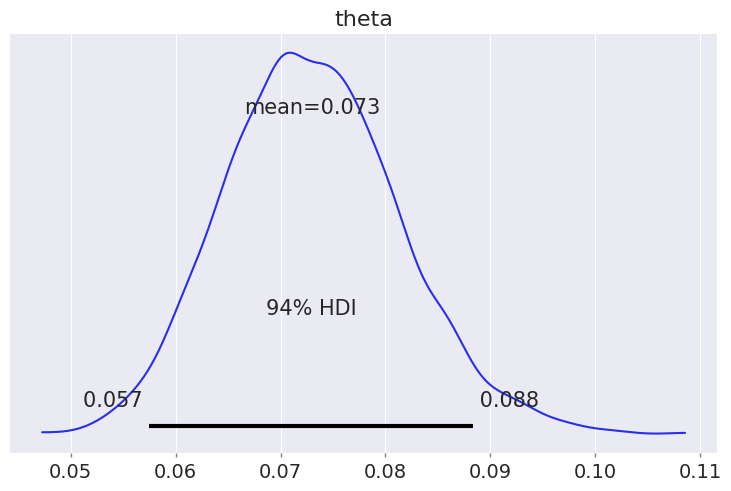

In [27]:
az.plot_posterior(idata)

In [28]:
az.summary(idata, kind="stats")

# Or az.summary(idata) if you want more than the mean, sd and HDI (we'll learn about it later)

,mean,sd,hdi_3%,hdi_97%
theta,0.073,0.008,0.057,0.088


---

# Frequentist Statistics

## MLE

In [29]:
# Basic summaries (reminder)
data = df["biotech"].to_numpy()

n = len(data)
k = data.sum()
theta_hat_analytic = k / n


print("Number of startups n", n)
print("Number of Biotechnology startups k", k)
print("Observed Biotechnology rate k/n", theta_hat_analytic)

# The unknown parameter theta is the probability that a startup is in Biotechnology.

Number of startups n 965
Number of Biotechnology startups k 70
Observed Biotechnology rate k/n 0.07253886010362694


#### Analytical MLE for the Binomial model

In [30]:
# For a Binomial model, the MLE has a simple closed-form solution:
#   theta_hat_MLE = k / n
#
# In this dataset:
#   theta_hat_MLE = number of Biotechnology startups / total startups

theta_hat_analytic = k / n

print("Analytical MLE for the Binomial model:")
print(f"theta_hat = k/n = {k}/{n} = {theta_hat_analytic}")

Analytical MLE for the Binomial model:
theta_hat = k/n = 70/965 = 0.07253886010362694


#### Log-likelihood: same MLE, better numerical behavior


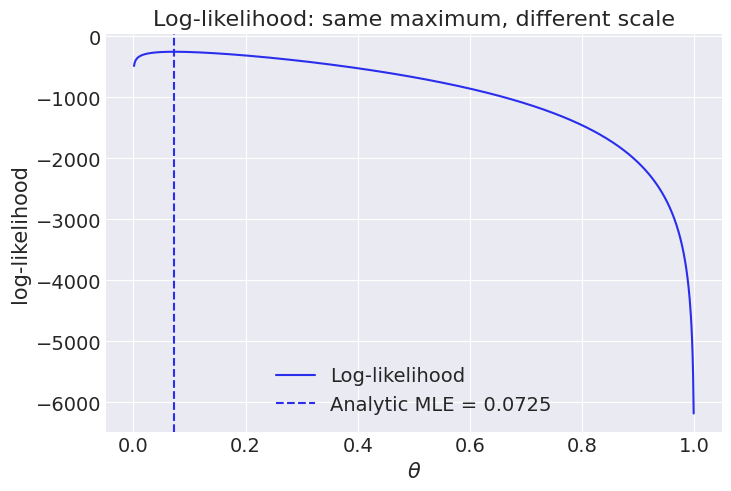

In [31]:
# With large datasets, multiplying many probabilities can produce extremely small numbers.
# Therefore, likelihood values can become numerically unstable.
#
# We usually use log-likelihood instead:
#   log-likelihood = log likelihood
#
# Since log is monotonic:
#   the theta that maximizes likelihood also maximizes log-likelihood.

from scipy import stats, special, optimize

# Candidate theta values for plotting the likelihood/log-likelihood curve
theta_grid = np.linspace(0.001, 0.999, 999)

def binomial_likelihood(theta, k, n):
    """
    Binomial likelihood: probability of observing k Biotechnology startups
    out of n startups, for each candidate theta.
    """
    return stats.binom.pmf(k, n=n, p=theta)


def binomial_loglikelihood(theta, k, n):
    """
    Binomial log-likelihood up to an additive constant.

    We omit log(n choose k), because it does not depend on theta.
    Omitting it does not change the MLE.
    """
    theta = np.asarray(theta, dtype=float)
    return special.xlogy(k, theta) + special.xlog1py(n - k, -theta)

loglik_grid = binomial_loglikelihood(theta_grid, k, n)

plt.figure()
plt.plot(theta_grid, loglik_grid, label="Log-likelihood")
plt.axvline(theta_hat_analytic, linestyle="--",
            label=f"Analytic MLE = {theta_hat_analytic:.4f}")
plt.xlabel(r"$\theta$")
plt.ylabel("log-likelihood")
plt.title("Log-likelihood: same maximum, different scale")
plt.legend()
plt.show()


# This is a useful place to say:
#   We did not change the statistical question.
#   We only changed the numerical scale.
#   The maximum is in the same place.


#### Numerical optimization

In [32]:
# A more general computational approach
# scipy.optimize minimizes functions.
# Since MLE requires maximizing log-likelihood, we minimize the negative log-likelihood.

def negative_binomial_loglikelihood(theta, k, n):
    """
    Negative log-likelihood for numerical optimization.
    """
    return -binomial_loglikelihood(theta, k, n)


opt_result = optimize.minimize_scalar(
    negative_binomial_loglikelihood,
    bounds=(0.001, 0.999),
    args=(k, n),
    method="bounded"
)

theta_hat_optim = opt_result.x

print("Numerical optimization MLE for the Binomial model:")
print(f"theta_hat = {theta_hat_optim:.4f}")

Numerical optimization MLE for the Binomial model:
theta_hat = 0.0725


In [33]:
comparison = pd.DataFrame({
    "Method": ["Analytic k/n", "Optimization"],
    "MLE estimate": [theta_hat_analytic, theta_hat_optim],
})

comparison["Absolute difference from analytic MLE"] = np.abs(
    comparison["MLE estimate"] - theta_hat_analytic
)

comparison


# The methods should give nearly the same answer.
# This links:
#   1. A formula: k/n
#   2. A general computational method: optimization


,Method,MLE estimate,Absolute difference from analytic MLE
0,Analytic k/n,0.072539,0.000000
1,Optimization,0.072537,0.000002


#### Sampling distribution of the MLE


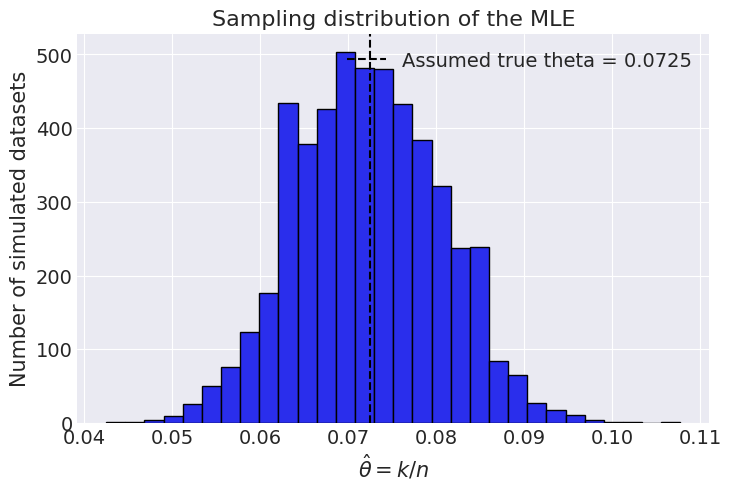

,Quantity,Value
0,Assumed true theta,0.072539
1,Mean of simulated theta_hat,0.072358
2,SD of simulated theta_hat,0.008232


In [34]:
# Frequentist uncertainty is about repeated sampling.
#
# The true theta is treated as fixed.
# The data would change if we repeated the study.
# Therefore, the estimate theta_hat = k/n would also change.
#
# Since we do not know the true theta, we use the observed MLE as a plausible value
# for demonstration.

assumed_true_theta = theta_hat_analytic
sample_size = n
num_simulated_datasets = 5000

simulated_k = rng.binomial(
    n=sample_size,
    p=assumed_true_theta,
    size=num_simulated_datasets
)

simulated_theta_hat = simulated_k / sample_size

plt.figure()
plt.hist(simulated_theta_hat, bins=30, edgecolor="black")
plt.axvline(assumed_true_theta, color='black',  linestyle="--", label=f"Assumed true theta = {assumed_true_theta:.4f}")
plt.xlabel(r"$\hat{\theta} = k/n$")
plt.ylabel("Number of simulated datasets")
plt.title("Sampling distribution of the MLE")
plt.legend()
plt.show()

sampling_summary = pd.DataFrame({
    "Quantity": ["Assumed true theta", "Mean of simulated theta_hat", "SD of simulated theta_hat"],
    "Value": [
        assumed_true_theta,
        simulated_theta_hat.mean(),
        simulated_theta_hat.std(ddof=1)
    ],
})

sampling_summary


# Even if theta is fixed, the estimate changes across repeated datasets.
# That variability is the sampling distribution of the estimator.


## CI

Observed MLE: 0.0725
Approximate 95% CI by Binomial inversion: [0.0570, 0.0900]


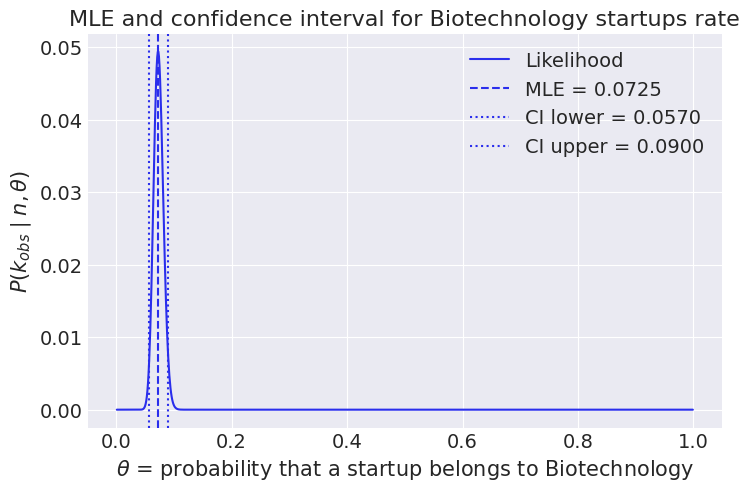

In [35]:
# Confidence interval by Binomial inversion

# Logic:
#   For each candidate theta, ask:
#     Would our observed number of Biotechnology startups be too extreme
#     if this theta were true?
#
# If the observed k is not too extreme under theta, we keep theta.
# The kept theta values form the confidence interval.

alpha = 0.05
k_obs = k
n_obs = n

theta_candidates = np.linspace(0.001, 0.999, 999)
accepted = []

for theta in theta_candidates:
    # Probability of observing k_obs or fewer acquired startups
    lower_tail = stats.binom.cdf(k_obs, n=n_obs, p=theta)

    # Probability of observing k_obs or more acquired startups
    upper_tail = 1 - stats.binom.cdf(k_obs - 1, n=n_obs, p=theta)

    # Keep theta values for which the observed result is not in the extreme tails
    if lower_tail > alpha / 2 and upper_tail > alpha / 2:
        accepted.append(theta)

ci_lower = min(accepted)
ci_upper = max(accepted)

print(f"Observed MLE: {theta_hat_analytic:.4f}")
print(f"Approximate 95% CI by Binomial inversion: [{ci_lower:.4f}, {ci_upper:.4f}]")


# Plot likelihood together with CI limits.
plt.figure()
plt.plot(theta_candidates, binomial_likelihood(theta_candidates, k_obs, n_obs), label="Likelihood")
plt.axvline(theta_hat_analytic, linestyle="--", label=f"MLE = {theta_hat_analytic:.4f}")
plt.axvline(ci_lower, linestyle=":", label=f"CI lower = {ci_lower:.4f}")
plt.axvline(ci_upper, linestyle=":", label=f"CI upper = {ci_upper:.4f}")
plt.xlabel(r"$\theta$ = probability that a startup belongs to Biotechnology")
plt.ylabel(r"$P(k_{obs} \mid n, \theta)$")
plt.title("MLE and confidence interval for Biotechnology startups rate")
plt.legend()
plt.show()


# Important wording:
#   Incorrect: There is a 95% probability that theta is inside this interval.
#   Correct: If we repeated the full procedure many times, about 95% of the intervals
#            would contain the true theta, assuming the model is correct.

#### Coverage simulation for the CI procedure


Estimated coverage over 300 experiments: 0.960


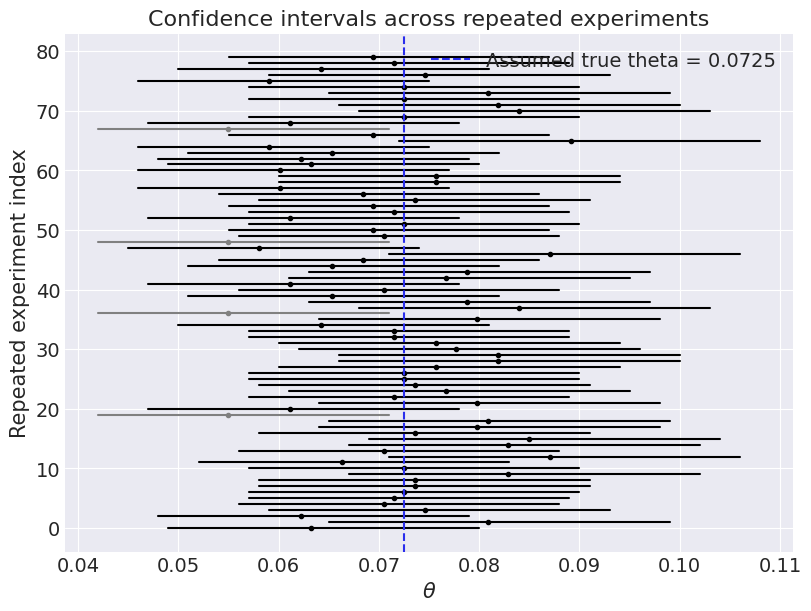

In [37]:
# Long-run interpretation of confidence intervals.
# We repeat the experiment many times:
#   1. Generate a dataset from an assumed true theta
#   2. Compute the CI for that dataset
#   3. Check whether the CI contains the assumed true theta
# If the method has approximately 95% coverage, around 95% of intervals
# should contain the true theta.


def binomial_ci_by_inversion(k_obs, n_obs, alpha=0.05, grid_size=999):
    """
    Approximate two-sided Binomial confidence interval by grid inversion.

    This function is written for teaching clarity rather than computational speed.
    """
    theta_candidates = np.linspace(0.001, 0.999, grid_size)
    accepted = []

    for theta in theta_candidates:
        lower_tail = stats.binom.cdf(k_obs, n=n_obs, p=theta)
        upper_tail = 1 - stats.binom.cdf(k_obs - 1, n=n_obs, p=theta)

        if lower_tail > alpha / 2 and upper_tail > alpha / 2:
            accepted.append(theta)

    if len(accepted) == 0:
        return np.nan, np.nan

    return min(accepted), max(accepted)


true_theta_for_coverage = theta_hat_analytic
n_for_coverage = n
num_experiments = 300

coverage_records = []

for experiment_id in range(num_experiments):
    k_sim = rng.binomial(n=n_for_coverage, p=true_theta_for_coverage)
    theta_hat_sim = k_sim / n_for_coverage
    lo, hi = binomial_ci_by_inversion(k_sim, n_for_coverage, alpha=0.05)
    contains_true = lo <= true_theta_for_coverage <= hi

    coverage_records.append({
        "experiment": experiment_id,
        "k": k_sim,
        "theta_hat": theta_hat_sim,
        "ci_lower": lo,
        "ci_upper": hi,
        "contains_true": contains_true,
    })

coverage_df = pd.DataFrame(coverage_records)
coverage_rate = coverage_df["contains_true"].mean()

print(f"Estimated coverage over {num_experiments} experiments: {coverage_rate:.3f}")


# Plot a subset of intervals for readability.
plot_df = coverage_df.head(80).copy()

plt.figure(figsize=(8, 6))
for _, row in plot_df.iterrows():
    color = "black" if row["contains_true"] else "gray"
    plt.plot([row["ci_lower"], row["ci_upper"]], [row["experiment"], row["experiment"]], color=color)
    plt.plot(row["theta_hat"], row["experiment"], marker="o", color=color, markersize=3)

plt.axvline(true_theta_for_coverage, linestyle="--", label=f"Assumed true theta = {true_theta_for_coverage:.4f}")
plt.xlabel(r"$\theta$")
plt.ylabel("Repeated experiment index")
plt.title("Confidence intervals across repeated experiments")
plt.legend()
plt.show()


#   - Each horizontal line is one interval from one simulated experiment.
#   - The vertical dashed line is the assumed true theta.
#   - Some intervals miss it.
#   - The confidence level describes the long-run behavior of the method.